In [13]:
from langgraph.graph import StateGraph,START,END
from typing import Annotated,TypedDict
from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import HumanMessage,AIMessage,BaseMessage
from pydantic import BaseModel 
from langgraph.checkpoint.memory import InMemorySaver
import os

In [5]:
load_dotenv()

MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")

if MISTRAL_API_KEY is None:
    raise ValueError("MISTRAL_API_KEY is not avaiable in env.")

In [6]:
llm = ChatMistralAI(
    model_name = 'open-mistral-nemo',
    temperature=0.7,
    max_tokens= 1024,
    api_key=os.environ["MISTRAL_API_KEY"]
)

response = llm.invoke([HumanMessage(content="How are you?\n")])
print(response.content)

Hello! I'm here and ready to assist you. How can I help you today?


In [7]:
# let's create a simple chatbot
# a chatbot which will generate me a joke and also give me explaination of the joke

In [8]:
# let's define the state

class Joke_chatbot(TypedDict):
    topic: str
    joke: str
    explaination: str

In [9]:
# define the node of the chatbot
def generate_joke(state: Joke_chatbot):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

def generate_joke_explaination(state: Joke_chatbot):
    prompt = f'generate a explaination for the joke {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explaination':response}

In [14]:
# let's define the graph
graph = StateGraph(Joke_chatbot)

# add node of the graph
graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_joke_explaination',generate_joke_explaination)

# add edge of the graph
graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_joke_explaination')
graph.add_edge('generate_joke_explaination',END)

checkpointer = InMemorySaver()

joke_bot_workflow = graph.compile(checkpointer=checkpointer)

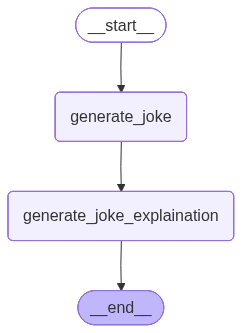

In [15]:
joke_bot_workflow

In [17]:
config1 = {"configurable": {"thread_id":'1'}}

joke_bot_workflow.invoke({"topic":"pizza"},config=config1)

{'topic': 'pizza',
 'joke': "Why did the pizza maker go broke? He just couldn't make enough dough.",
 'explaination': 'The joke "Why did the pizza maker go broke? He just couldn\'t make enough dough" is a play on words, or a pun, that combines two different meanings of the word "dough."\n\n1. **Primary Meaning (Pizza Context)**: In the context of a pizza maker, "dough" refers to the mixture of flour, water, yeast, and other ingredients used to make pizza crust. The pizza maker in the joke is trying to make more pizza crust, but he\'s struggling to make enough of it.\n\n2. **Secondary Meaning (Money Context)**: Outside of the pizza context, "dough" is also a slang term for money. The joke implies that the pizza maker is also having trouble making enough money, which is why he went broke.\n\nSo, the humor in this joke comes from the double meaning of "dough," and the punchline "He just couldn\'t make enough dough" is funny because it could mean either he couldn\'t make enough pizza crust